# Notebook 0 - Input data preparation

<hr>
This key module helps the user prepare all the input data (currently for module 1)

Prepared by Dario Spiller, Geospatial Unit at the Land and Water Division, FAO HQ
<hr>


In [4]:
'''import supporting libraries'''
# import pyaez
import matplotlib.pyplot as plt
import numpy as np
import os
#import pandas as pd
#try:
#    from osgeo import gdal
#except:
#    import gdal
import sys
#import geopandas as gpd
import cavapy
#import xarray as xr
#import rasterio
#from rasterio.transform import from_bounds
#from rasterio.crs import CRS
#from rasterio.plot import show
#from rasterio.mask import mask
#from rasterio.features import rasterize
#from rasterio.warp import reproject, Resampling

#os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
#gdal.UseExceptions()

In [5]:
# Set the working directory
work_dir = r'/workspaces/Python-AEZ-FAO'  # Please change this to your working directory
os.chdir(work_dir)
sys.path.append(work_dir)
os.getcwd()


'/workspaces/Python-AEZ-FAO'

In [6]:
from module0 import pre_proc_utilities

In [7]:

import importlib
import module0.pre_proc_utilities
#importlib.reload(module0.pre_proc_utilities)


<module 'module0.pre_proc_utilities' from '/workspaces/Python-AEZ-FAO/module0/pre_proc_utilities.py'>

# Input data from the user

In [8]:
country_name = 'Togo'
years_list = [1980]
rcp = "rcp26"
gcm = "MOHC" # [MOHC, NCC, MPI]
rcm = 'REMO' # [ICTP, REMO] 
historical = True


# Loading the reference UN shapefile (level 1)

In [9]:
country_name = country_name.lower()
AOI = pre_proc_utilities.get_UN_country(country_name, thr=3, return_gdf=False)

The country "Togo" was selected from the UN  database.


# Loading climate data 

In [ ]:
years_up_to = np.max([np.max(years_list)+1, 2007])   
years_obs = range(1980,np.min([np.max(years_list)+1,2019]))
country_name_capitalized = country_name.capitalize()

if np.max(years_list) < 2007:
    # For historical data bias correction is not needed
    bias_correction = False
else:
    bias_correction = True
    
CAVA_climate_data = cavapy.get_climate_data(country=country_name_capitalized, 
                                             cordex_domain="AFR-22", 
                                             buffer=1,
                                             rcp=rcp, 
                                             gcm=gcm, 
                                             rcm=rcm, 
                                             num_processes=10,
                                             years_up_to=years_up_to, 
                                             obs=True, 
                                             bias_correction=bias_correction, 
                                             historical=historical, 
                                             years_obs=years_obs)


print('CAVA data fully retrieved!')
ds = CAVA_climate_data

2025-11-19 17:16:29,524 | climate.URL-validation-observations | 988:130674425386496 [INFO]: https://hub.ipcc.ifca.es/thredds/dodsC/fao/observations/ERA5/0.25/ERA5_025.ncml
2025-11-19 17:16:30,615 | climate.sfcWind-observations | 3346:130673400071872 [INFO]: Establishing connection to ERA5 data for sfcWind(sfcwind)
2025-11-19 17:16:30,644 | climate.tasmax-observations | 3343:130673400071872 [INFO]: Establishing connection to ERA5 data for tasmax(t2mx)
2025-11-19 17:16:30,660 | climate.rsds-observations | 3347:130673400071872 [INFO]: Establishing connection to ERA5 data for rsds(ssrd)
2025-11-19 17:16:30,661 | climate.tasmin-observations | 3344:130673400071872 [INFO]: Establishing connection to ERA5 data for tasmin(t2mn)
2025-11-19 17:16:30,672 | climate.pr-observations | 3342:130673400071872 [INFO]: Establishing connection to ERA5 data for pr(tp)
2025-11-19 17:16:30,672 | climate.hurs-observations | 3345:130673400071872 [INFO]: Establishing connection to ERA5 data for hurs(hurs)
2025-11

## Exporting CAVA data

In [ ]:
pre_proc_utilities.export_cava_data(ds, years_list, output_folder='./data_input/CAVA_data/')

## Defining the rasterized country AOI

In [ ]:
pre_proc_utilities.rasterize_country_from_geodataframe(ds, AOI, country_name, output_dir='./data_input/')

## Defining the DEM for the AOI at the original resolution

In [ ]:
DEM_raster_path = r'./data_input/DEM/altmed30s.tif'
pre_proc_utilities.clip_raster_with_geometry(DEM_raster_path, AOI, country_name, output_dir='./data_input/')

## Defining the DEM for the AOI at the scaled resolution

Unique values: [7.0 23.0 36.0 61.0 72.0 98.0 100.0 110.0 112.0 115.0]


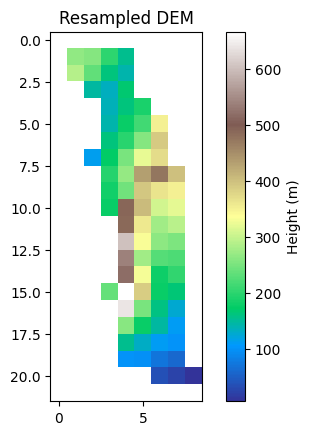

In [7]:
elv = pre_proc_utilities.process_raster(INPUT_raster_path = './data_input/DEM/altmed30s.tif', 
                  ref_raster_path = f'./data_input/{country_name}_rasterized.tif',
                  output_clipped_path = f'./data_input/{country_name}_elevation_resampled_clipped.tif',
                  ref_geom = AOI.geometry, plot=True, title = 'Resampled DEM', colorbar_label = 'Height (m)', cmap='terrain')


## Defining the LULC layer for the AOI at the scaled resolution

Unique values: [3.0 4.0 5.0 --]


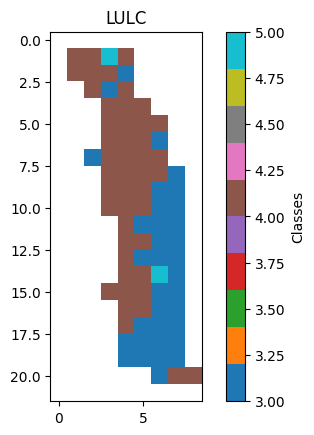

In [8]:
lulc = pre_proc_utilities.process_raster(INPUT_raster_path = './data_input/LULC/soil_regime_CRUTS32_Hist_8110.tif', 
                  ref_raster_path = f'./data_input/{country_name}_rasterized.tif',
                  output_clipped_path = f'./data_input/{country_name}_lulc_resampled_clipped.tif',
                  ref_geom = AOI.geometry, plot=True, title = 'LULC', colorbar_label = 'Classes', cmap='tab10')